In [1]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("../data/archive/combine.csv",low_memory=False)
df.columns=df.columns.str.strip()
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [4]:
df.shape

(2214469, 79)

In [6]:
df['Label']= df['Label'].str.strip().str.upper()

In [8]:
df['Label'].value_counts()

Label
BENIGN              1672837
DOS HULK             231073
PORTSCAN             158930
DDOS                 128027
DOS GOLDENEYE         10293
DOS SLOWLORIS          5796
DOS SLOWHTTPTEST       5499
BOT                    1966
INFILTRATION             36
HEARTBLEED               11
Name: count, dtype: int64

In [18]:
df['Label'] =df['Label'].replace({ 'DOS HULK':'DOS',
                                   'DOS GOLDENEYE':'DOS',
                                   'DOS SLOWLORIS':'DOS',
                                   'DOS SLOWHTTPTEST':'DOS'})

In [17]:
df= df[df['Label'].isin(['BENIGN','DOS','DDOS','PORTSCAN'])].copy()

In [26]:
print("Class distribution after Label mapping and filtering",df['Label'].value_counts())

Class distribution after Label mapping and filtering Label
BENIGN      1527202
DOS          193745
DDOS         128016
PORTSCAN      90694
Name: count, dtype: int64


In [25]:
print("Shape before cleaning",df.shape)

Shape before cleaning (1939657, 79)


In [19]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)

In [20]:
df.dropna(inplace=True)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.reset_index(drop=True,inplace=True)

In [23]:
print("Shape after cleaning ",df.shape)

Shape after cleaning  (1939657, 79)


In [28]:
x=df.drop('Label',axis=1)
y=df['Label']

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.3,
    random_state=42,
    stratify=y)

In [31]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced")

In [32]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [36]:
y_pred=model.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred,digits=6))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.9986406552351099
              precision    recall  f1-score   support

      BENIGN   0.999199  0.999116  0.999157    458161
        DDOS   0.999818  0.999844  0.999831     38405
         DOS   0.998177  0.998675  0.998426     58124
    PORTSCAN   0.988573  0.988864  0.988718     27208

    accuracy                       0.998641    581898
   macro avg   0.996442  0.996625  0.996533    581898
weighted avg   0.998641  0.998641  0.998641    581898

[[457756      7     93    305]
 [     6  38399      0      0]
 [    71      0  58047      6]
 [   290      0     13  26905]]


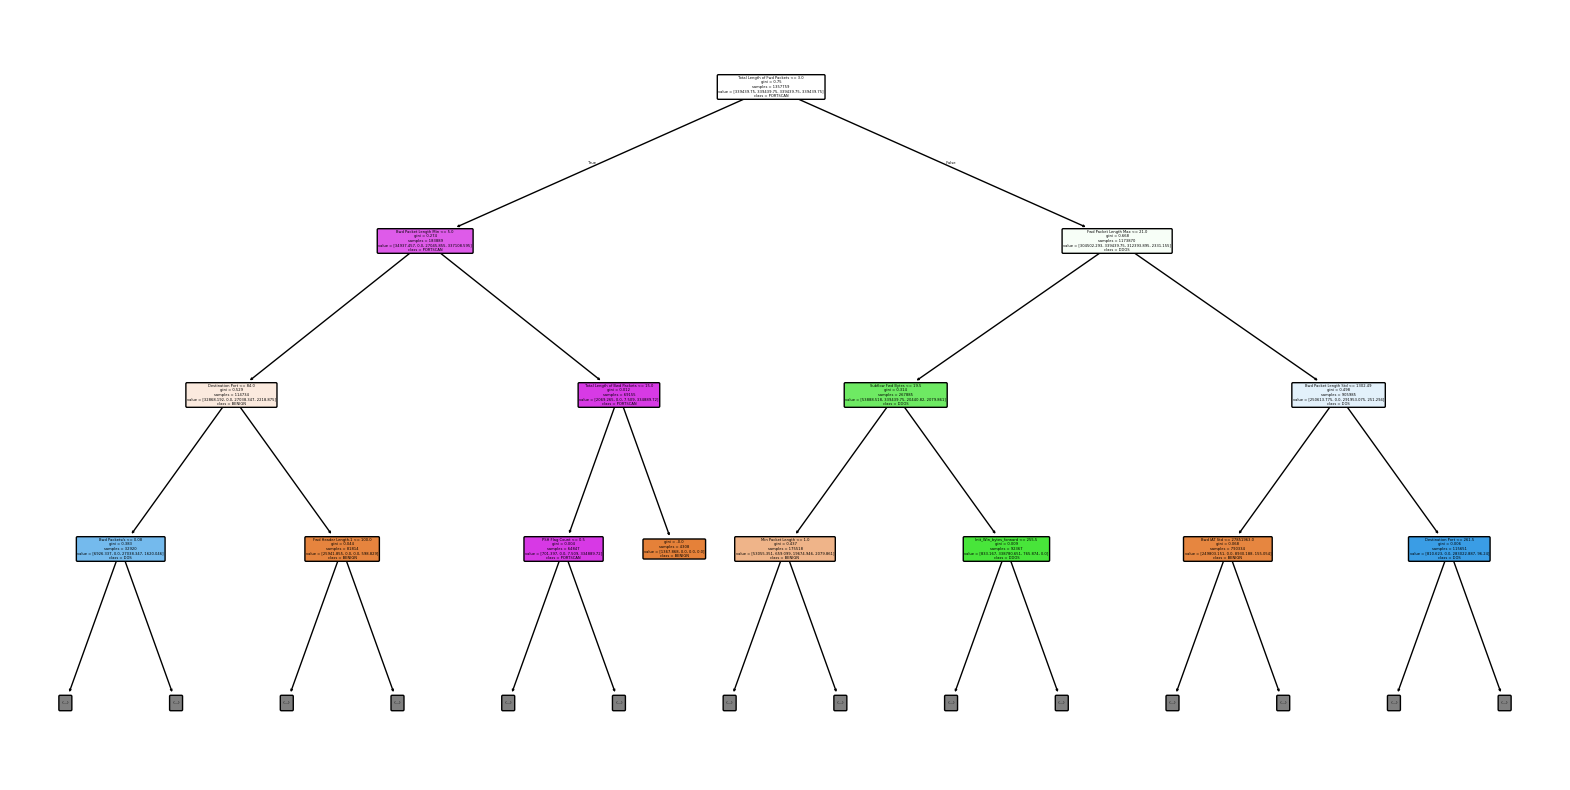

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

In [43]:
import joblib

joblib.dump(model, "../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']